# Ensembling

So far, we have trained and evaluated **single** models. In practice, some of the most reliable systems in machine learning do not rely on a lone network, but on an ensemble of several models that look at the same input and make a joint decision. The basic idea is simple: if each model makes slightly different errors, combining their predictions can reduce variance and improve generalization.

Instead of deploying a single network, we can train several networks (with different architectures, initializations, data orders, or augmentations) and combine them. Simple strategies such as averaging logits or taking a majority vote often give a measurable accuracy gain over the best individual model, especially when the ensemble members are reasonably diverse. In this notebook we will build such an ensemble from multiple CNNs trained on the same task, and compare the behavior of individual models with a simple voting scheme.

Although there is not a single universally acknowledged “first DL ensemble paper”, here are two historically important anchors:

- **Pre‑deep‑learning neural network ensembles / committees**

The idea of combining multiple neural networks (committee machines) for better generalization predates modern deep learning by decades, e.g. Krogh & Vedelsby “Neural network ensembles, cross validation, and active learning” (NIPS 1994) [PDF](https://scispace.com/pdf/neural-network-ensembles-cross-validation-and-active-2nxdfh7lc1.pdf).

- **Deep CNN ensemble in the modern DL era**

In the ImageNet breakthrough, Krizhevsky, Sutskever & Hinton (AlexNet, 2012) trained multiple CNNs and averaged their predicted probabilities as the final system, effectively using a deep ensemble. Krizhevsky, Sutskever & Hinton, “ImageNet Classification with Deep Convolutional Neural Networks” (NIPS 2012) [PDF](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)







## Building Ensembles

In practice, an ensemble only helps if its members are not all making the same mistakes. There are several simple ways to create this kind of diversity:

- Independent trainings with different randomness

We can train the same architecture multiple times with different random seeds, shuffling orders, and data augmentations. Even though the models see the “same” dataset, they follow different optimization trajectories and converge to slightly different solutions. In the next sections we will see how to combine these multiple predictions into a single decision.

- Cross‑validation as an ensemble generator

If we split the data into k folds, we can train one model per fold (each time using a different subset for training and validation). This uses cross‑validation both to estimate performance and to generate a set of models that have seen slightly different data, which increases diversity.

- Architectural diversity

Another way to build an ensemble is to mix models with different architectures or hyper‑parameters. For example, CNNs with different depths, kernel sizes, or regularization settings. Even when trained on the same data, these architectures tend to represent features differently and make different errors, so combining them often improves robustness over any single model.

## Imports and Aux functions

In [1]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

Using the architecture from previous notebooks. 

In [2]:
def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    with torch.no_grad():
        for i, (images, targets) in enumerate(data_loader):
            
            # forward pass, compute the output of the model for the current batch
            outputs = model(images.to(device))

            # "max" returns a namedtuple (values, indices) where values is the maximum 
            # value of each row of the input tensor in the given dimension dim; 
            # indices is the index location of each maximum value found (argmax).
            # the argmax effectively provides the predicted class number        
            _, preds = torch.max(outputs, dim=1)

            correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()



class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        
        # Block 1
        self.conv1 = torch.nn.Conv2d(3, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()
        
        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()
        
        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()
        
        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()
        
        self.maxpool2 = torch.nn.MaxPool2d(2)
    
        # Dropout (p=0.5 drops 50% of the neurons randomly during training)
        self.dropout = torch.nn.Dropout(p=0.5)

        # Fully Connected (GAP outputs 48 channels as scalars -> 48 inputs)
        self.fc1 = torch.nn.Linear(48, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 32, 32)
        x = self.conv1(x)       # -> (bs, 16, 30, 30)
        x = self.bn1(x)
        x = self.relu1(x)
        
        x = self.conv2(x)       # -> (bs, 32, 28, 28)
        x = self.bn2(x)
        x = self.relu2(x)
        
        x = self.maxpool1(x)    # -> (bs, 32, 14, 14)
        
        x = self.conv3(x)       # -> (bs, 48, 12, 12)
        x = self.bn3(x)
        x = self.relu3(x)
        
        x = self.conv4(x)       # -> (bs, 48, 10, 10)
        x = self.bn4(x)
        x = self.relu4(x)
        
        x = self.maxpool2(x)    # -> (bs, 48, 5, 5)
        
        # Apply GAP using torch.mean
        x = torch.mean(x, dim=[2, 3])   # -> (bs, 48)
        
        # Apply Dropout
        x = self.dropout(x)
        
        # Classifier
        x = self.fc1(x)         # -> (bs, 10)

        return x


class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_delta
        self.min_val_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    

## Settings

In this notebook we are using the 5 runs trained in the previous notebook.  

In [3]:
RUNS = 5
PATH_TEST_SET = 'd:/vcpi/gtsrb/test_A'


In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [5]:

transform = v2.Compose(
    [v2.Resize((32,32)), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

test_set = torchvision.datasets.ImageFolder(root = PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = 128)


## Loading the 5 runs

In [6]:

models = []
acc = []

for i in range(RUNS):

    reload = torch.load(f'aug_II_{i}.pt')
    model = Conv_II(len(test_set.classes))
    model.load_state_dict(reload['model'])
    model.to(device)
    models.append(model)
    acc.append(evaluate(models[i], test_loader))



### Evaluating the individual models

Accuracy - mean:  0.9941486954689026  max:  0.9959232807159424  min:  0.9928057789802551


(0.99, 1.0)

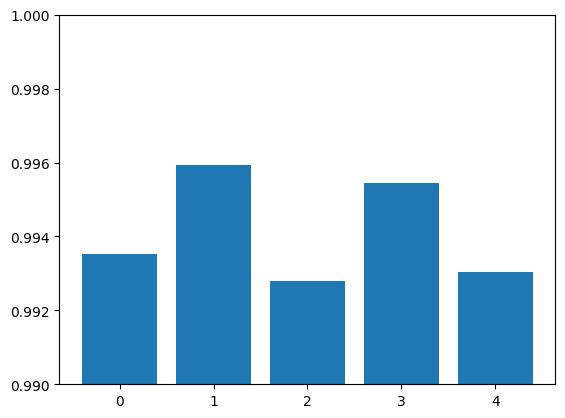

In [7]:

index = [i for i in range(RUNS)]
  
plt.bar(index, acc)
print('Accuracy - mean: ', np.mean(acc), ' max: ',np.max(acc), ' min: ', np.min(acc))
plt.ylim(0.99,1.0)

## Ensemble strategy

Given N trained models, there are several simple ways to combine their outputs into a single prediction:

- **Majority vote on predicted labels (hard voting)**

Each model outputs a class label; we count how many models vote for each class and pick the class with the highest vote count. This is the strategy we implement in this notebook, using only the argmax from each network.

- **Averaging class probabilities (soft voting)**

If each model outputs a vector of class probabilities (or logits passed through softmax), we can average these probability vectors across models and then take the argmax of the averaged distribution. This uses more information than hard voting and can work slightly better when probabilities are reasonably calibrated.

- **Weighted schemes (for both hard and soft voting)**

Instead of treating all models equally, we can assign a weight to each model based on its validation performance, diversity, or some other criterion. In hard voting, a stronger model might contribute more than one “vote”; in soft voting, we can take a weighted average of the probability vectors. This allows us to favor models that generalize better while still benefiting from the ensemble.

- **Stacking (meta‑learning how to combine models)**

In stacking, we train a separate meta‑model that takes as input the outputs of all base models (typically their logits or probabilities) and learns to produce the final prediction. The base models are first trained on the original data; then their predictions  on a held-out set become inputs for the meta‑model. Stacking is more flexible than simple voting, but also more prone to overfitting if the meta‑model is too powerful or not trained with a proper held‑out set.





# Coding

In [18]:

def get_labels_logits_and_preds(models):

    runs = len(models)

    with torch.no_grad():
        logits = [[] for _ in range(runs)]
        labels = []

        for images, labs in test_loader:

            images = images.to(device)
            labels.extend(labs.tolist())
            
            for i in range(runs):
                logits[i].extend(models[i](images).cpu())


    return labels, logits

labels, logits = get_labels_logits_and_preds(models)

### Soft Voting

First we collect the class which has the highest sum of the logits across all models. Then we check the percentage of the correct predictions.

In [19]:
def get_class_from_logits_sum(logits):

    sum_logits = []

    num_samples = len(logits[0])

    for i in range(num_samples):

        log = logits[0][i].clone()
        for m in range(1, RUNS):
            log += logits[m][i]
        sum_logits.append(torch.argmax(log).item())
    return(sum_logits)
    
class_logits_soft = get_class_from_logits_sum(logits)    

In [20]:
print(class_logits_soft[3990:4000])
print(labels[3990:4000])

[7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
[7, 7, 7, 7, 7, 7, 7, 7, 7, 7]


In [21]:
# accuracy of soft-voting ensemble
correct_soft = sum(1 for y, p in zip(labels, class_logits_soft) if y == p)
acc_soft = correct_soft / len(labels)

print("Soft-voting (logits-sum) ensemble accuracy:", acc_soft)

Soft-voting (logits-sum) ensemble accuracy: 0.9952038369304557


### Hard Voting

First collect all the class predictions for each sample. Then sum the votes and evaluate.

*preds* will store all the class predictions for each test set image

In [22]:
preds = [[] for _ in range(len(labels)) ]

for index in range(len(labels)):
    preds[index] = [np.argmax(logits[m][index].cpu().numpy()) for m in range(RUNS)]

In [23]:
print(preds[4000])

[7, 7, 7, 7, 7]


Here we are implementing hard‑voting behavior and inspecting how often the ensemble corrects or amplifies individual errors.

In [24]:
import collections 

def get_stats(labels, class_preds):

    all_correct = 0
    all_incorrect = 0
    maj_vote = 0
    maj_wrong = 0
    tie = 0
    count = 0

    for k in range(len(labels)):

        counter = collections.Counter(class_preds[k])
        if len(counter) == 1:
            if counter.most_common(1)[0][0] == labels[k]:
                all_correct += 1
            else:
                all_incorrect += 1
        else:
            aux = counter.most_common(2)
            if aux[0][1] > aux[1][1] and aux[0][0] == labels[k]:
                maj_vote += 1
            if aux[0][1] > aux[1][1] and aux[0][0] != labels[k]:
                maj_wrong += 1
            elif aux[0][1] == aux[1][1]:
                tie += 1

        count += 1 
        
    return [count, all_correct, all_incorrect, maj_vote, tie, maj_wrong]
    
    
res = get_stats(labels, preds)
print('total: ', res[0])
print('All correct: ', res[1])
print('All incorrect: ', res[2])
print('Majority correct: ', res[3])
print('Tie Vote: ', res[4])
print('Majority Wrong: ', res[5])
print('Percentage right (all correct + majority correct): ', (res[1]+res[3])/res[0])

total:  4170
All correct:  4125
All incorrect:  7
Majority correct:  24
Tie Vote:  0
Majority Wrong:  14
Percentage right (all correct + majority correct):  0.9949640287769784


Based on the results we see that in 24 cases the ensemble fixes at least one model’s error, 
while in 14 it amplifies a wrong majority.

## Conclusion

When testing the individual models and the ensemble we got the following results:

| Model type              | Accuracy (%) |
|-------------------------|-------------:|
| Best single model       | 99.60        |
| Average single model    | 99.41        |
| Worst single model       | 99.29        |
| Ensemble (majority vote, hard)  | 99.50        |
| Ensemble (soft vote, logits sum)| 99.52        |

Even in this high‑accuracy regime, combining several independently trained CNNs through a simple voting scheme yields a small but measurable gain over the average individual model, while remaining competitive with the best single model. In this example, soft voting (99.52%) performs very similarly to hard majority voting (99.50%), which is typical when the individual models are already strong and fairly well calibrated.

This illustrates a key property of ensembles: by aggregating slightly different decision boundaries, they can reduce variance and make predictions more robust to the idiosyncrasies of any particular training run. In larger or noisier problems the gap between the best single model and the ensemble is often more pronounced, but this experiment already shows that ensembling is a practical tool for squeezing extra performance out of models we have already trained.

## Appendix

Visualization of samples that were majority decided.

Here we present one example where a majority decision helps (the ensemble corrects at least one model’s error) and one where it hurts (the majority is wrong even though at least one model was correct).

Ensemble FIXES errors:

Index: 264
True label: 1 (00001)
Per-model predictions: [1, 1, 2, 1, 1]
Soft-vote prediction: 1 (00001)


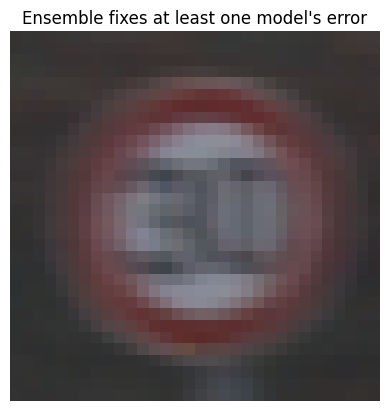


Ensemble AMPLIFIES errors:

Index: 1666
True label: 3 (00003)
Per-model predictions: [5, 3, 5, 5, 5]
Soft-vote prediction: 5 (00005)


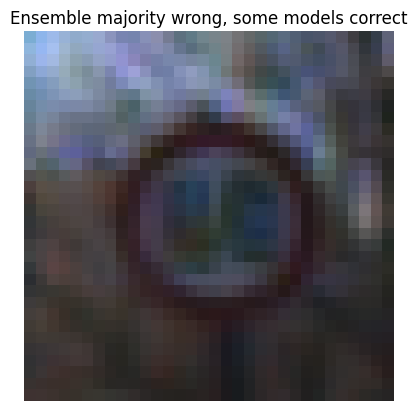

In [28]:
import matplotlib.pyplot as plt

def show_example(idx, title):
    img, _ = test_set[idx]  # transformed image
    # assumes transform produced floats in [0, 1]
    img_np = img.permute(1, 2, 0).numpy()
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(title)
    plt.show()

def format_case(idx, labels, preds, class_logits_soft):
    true = labels[idx]
    hard_votes = preds[idx]
    soft_pred = class_logits_soft[idx]
    return (
        f"Index: {idx}\n"
        f"True label: {true} ({test_set.classes[true]})\n"
        f"Per-model predictions: {hard_votes}\n"
        f"Soft-vote prediction: {soft_pred} ({test_set.classes[soft_pred]})"
    )

# case where at least one model is wrong, but ensemble (soft) is correct
fix_idx = None
for i in range(len(labels)):
    if labels[i] == class_logits_soft[i]:  # ensemble correct
        if any(p != labels[i] for p in preds[i]):  # at least one model wrong
            fix_idx = i
            break

if fix_idx is not None:
    print("Ensemble FIXES errors:\n")
    print(format_case(fix_idx, labels, preds, class_logits_soft))
    show_example(fix_idx, "Ensemble fixes at least one model's error")
else:
    print("No example found where ensemble fixes an individual error.")

# case where majority (hard) is wrong, but at least one model is correct
worsen_idx = None
for i in range(len(labels)):
    true = labels[i]
    hard_vote = max(set(preds[i]), key=preds[i].count)  # majority class
    if hard_vote != true and any(p == true for p in preds[i]):
        worsen_idx = i
        break

if worsen_idx is not None:
    print("\nEnsemble AMPLIFIES errors:\n")
    print(format_case(worsen_idx, labels, preds, class_logits_soft))
    show_example(worsen_idx, "Ensemble majority wrong, some models correct")
else:
    print("No example found where ensemble amplifies an error.")